# 1. Introduction
This notebook evaluates end-to-end latency in VisionInput, from camera capture through MediaPipe inference to ViGEm controller output, to answer RQ2: does the pipeline satisfy real-time responsiveness. The dissertation non-functional requirement is a median latency of 33 ms or lower, aligned with a 30 fps frame interval. Following Brown (2016, p.169), the evaluation reports both central tendency and tail behaviour, so conclusions are not based on averages alone. The data source is merged_logs.xlsx, a merged benchmark export from multiple logging sessions and camera configurations, including native USB and virtual webcam pipelines where labels are available in the merged file.

## 2. Data Loading and Cleaning (Purpose Before Code)
This cell loads the merged workbook, validates required columns, coerces latency to numeric, and standardizes camera labels before any statistics are computed. This matters for evaluation validity because RQ2 conclusions depend on comparable and non-null latency samples rather than mixed raw log formats. Methodologically, numeric coercion with null removal prevents invalid strings from biasing distributions, and source_type assignment provides the basis for Camo-versus-native comparison where camera provenance exists in the merged export.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

sns.set_theme(style='whitegrid', context='talk')

DEADLINE_MS = 33.33  # 30fps frame budget
NFR_TARGET = 33.0    # NFR target for median

cwd = Path.cwd()
search_roots = [cwd.parent, cwd]
candidate_paths = []
for root in search_roots:
    candidate_paths.extend([
        root / 'merged_logs.xlsx',
        root / 'logs' / 'merged_logs.xlsx',
    ])

# Keep order while removing duplicates.
candidate_paths = list(dict.fromkeys(candidate_paths))
data_path = next((p for p in candidate_paths if p.exists()), None)
if data_path is None:
    raise FileNotFoundError('Could not find merged_logs.xlsx in current workspace roots.')

df = pd.read_excel(data_path)

# Support both per-trial latency logs and benchmark summary exports.
latency_source = None
for candidate in ['latency_ms', 'loop_ms', 'loop_total_ms_per_frame']:
    if candidate in df.columns:
        latency_source = candidate
        break

if latency_source is None:
    raise ValueError(
        'Missing latency column. Expected one of: latency_ms, loop_ms, loop_total_ms_per_frame. '
        f'Found columns: {list(df.columns)}'
    )

if latency_source != 'latency_ms':
    df['latency_ms'] = df[latency_source]

if 'camera_label' not in df.columns:
    df['camera_label'] = 'Unknown'

df = df.copy()
df['latency_ms'] = pd.to_numeric(df['latency_ms'], errors='coerce')
df = df.dropna(subset=['latency_ms'])
df['camera_label'] = df['camera_label'].fillna('Unknown').astype(str).str.strip()
df.loc[df['camera_label'].eq(''), 'camera_label'] = 'Unknown'
df['source_type'] = np.where(
    df['camera_label'].str.contains('Camo', case=False, na=False),
    'Camo',
    'Native'
 )

# Normalize stage columns so downstream figures can use consistent names.
stage_aliases = {
    'capture_ms': ['capture_ms', 'capture_ms_per_frame'],
    'preprocess_ms': ['preprocess_ms', 'preprocess_ms_per_frame'],
    'mediapipe_ms': ['mediapipe_ms', 'mediapipe_ms_per_frame'],
    'output_ms': ['output_ms', 'output_ms_per_frame'],
    'loop_ms': ['loop_ms', 'loop_total_ms_per_frame'],
}

for canonical, candidates in stage_aliases.items():
    for candidate in candidates:
        if candidate in df.columns:
            candidate_values = pd.to_numeric(df[candidate], errors='coerce')
            if canonical in df.columns:
                df[canonical] = pd.to_numeric(df[canonical], errors='coerce').fillna(candidate_values)
            else:
                df[canonical] = candidate_values
            break

print(f'Loaded {len(df):,} latency rows from: {data_path}')
print(f'Using latency source column: {latency_source}')
display(df.head())

Loaded 10,233 latency rows from: c:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\merged_logs.xlsx
Using latency source column: latency_ms


,camera_label,timestamp,run_tag,camera_resolution,backend,negotiated_fourcc,mode,duration_s,frames,fps,...,norm_x,norm_y,fps_rolling_1s,capture_ms,preprocess_ms,mediapipe_ms,output_ms,loop_ms,read_failed_count,source_type
12,Cisco Desk Camera_JHI,11:00:42,Native,1920x1080,DSHOW (700),YUY2,NaN,NaN,NaN,NaN,...,-0.379,1.000,29.93,1.65,3.66,22.94,0.17,31.87,0.0,Native
13,Cisco Desk Camera_JHI,11:00:54,Native,1920x1080,DSHOW (700),YUY2,NaN,NaN,NaN,NaN,...,-0.058,-0.419,30.00,8.06,3.80,22.11,0.24,37.35,0.0,Native
14,Cisco Desk Camera_JHI,11:00:56,Native,1920x1080,DSHOW (700),YUY2,NaN,NaN,NaN,NaN,...,1.000,0.328,29.38,1.60,3.32,29.25,0.16,37.66,0.0,Native
15,Cisco Desk Camera_JHI,11:00:56,Native,1920x1080,DSHOW (700),YUY2,NaN,NaN,NaN,NaN,...,-0.372,-0.361,29.17,1.56,3.58,22.11,0.14,30.60,0.0,Native
16,Cisco Desk Camera_JHI,11:00:56,Native,1920x1080,DSHOW (700),YUY2,NaN,NaN,NaN,NaN,...,-0.818,-0.535,28.71,1.61,3.37,29.87,0.11,38.02,0.0,Native


### Data Loading and Cleaning
This cell loads the merged workbook, validates required columns, coerces latency to numeric, and standardizes camera labels before any statistics are computed. The current run yields 10,233 valid latency rows across multiple camera labels, providing a comprehensive evaluation dataset that supports both overall and camera-level comparison with improved statistical power.

In [2]:
lat = df['latency_ms']
n_trials = int(lat.count())
compliance_mask = lat <= DEADLINE_MS
outlier_mask = lat > 100

table_4_1 = pd.DataFrame({
    'metric': [
        'n_trials', 'min_ms', 'max_ms', 'mean_ms', 'median_ms', 'std_ms',
        'p90_ms', 'p95_ms', 'p99_ms', 'compliance_rate_pct', 'outlier_count_gt_100ms', 'nfr_verdict'
    ],
    'value': [
        n_trials,
        lat.min(),
        lat.max(),
        lat.mean(),
        lat.median(),
        lat.std(ddof=1),
        lat.quantile(0.90),
        lat.quantile(0.95),
        lat.quantile(0.99),
        compliance_mask.mean() * 100,
        int(outlier_mask.sum()),
        'PASS' if lat.median() <= NFR_TARGET else 'FAIL'
    ]
})

table_4_1_styled = table_4_1.style.format({
    'value': lambda x: f'{x:.2f}' if isinstance(x, (float, np.floating)) else f'{x}'
}).set_caption('Table 4.1 - Overall Latency Statistics')
display(table_4_1_styled)

per_camera = (
    df.groupby('camera_label', dropna=False)['latency_ms']
      .agg(n='count', median='median', mean='mean', std='std', max='max')
      .reset_index()
)
comp_per_camera = (
    df.assign(is_compliant=df['latency_ms'] <= DEADLINE_MS)
      .groupby('camera_label', dropna=False)['is_compliant']
      .mean()
      .mul(100)
      .reset_index(name='compliance_pct')
)
table_4_2 = per_camera.merge(comp_per_camera, on='camera_label', how='left')
table_4_2 = table_4_2[['camera_label', 'n', 'median', 'mean', 'std', 'compliance_pct', 'max']]

table_4_2_styled = table_4_2.style.format({
    'n': '{:,.0f}',
    'median': '{:.2f}',
    'mean': '{:.2f}',
    'std': '{:.2f}',
    'compliance_pct': '{:.2f}',
    'max': '{:.2f}'
}).set_caption('Table 4.2 - Per-Camera Latency Breakdown')
display(table_4_2_styled)

table_4_3 = (
    df.assign(is_compliant=df['latency_ms'] <= DEADLINE_MS, is_outlier=df['latency_ms'] > 100)
      .groupby('source_type', dropna=False)
      .agg(
          n=('latency_ms', 'count'),
          median_ms=('latency_ms', 'median'),
          mean_ms=('latency_ms', 'mean'),
          std_ms=('latency_ms', 'std'),
          compliance_pct=('is_compliant', lambda s: s.mean() * 100),
          outliers_gt_100ms=('is_outlier', 'sum')
      )
      .reset_index()
)

table_4_3_styled = table_4_3.style.format({
    'n': '{:,.0f}',
    'median_ms': '{:.2f}',
    'mean_ms': '{:.2f}',
    'std_ms': '{:.2f}',
    'compliance_pct': '{:.2f}',
    'outliers_gt_100ms': '{:,.0f}'
}).set_caption('Table 4.3 - Camo vs Native Comparison')
display(table_4_3_styled)

stats_cache = {
    'median': float(lat.median()),
    'p50': float(lat.quantile(0.50)),
    'p90': float(lat.quantile(0.90)),
    'p95': float(lat.quantile(0.95)),
    'p99': float(lat.quantile(0.99)),
    'verdict': 'PASS' if float(lat.median()) <= NFR_TARGET else 'FAIL'
}

,metric,value
0,n_trials,10233
1,min_ms,15.72
2,max_ms,784.47
3,mean_ms,30.63
4,median_ms,29.58
5,std_ms,14.57
6,p90_ms,37.99
7,p95_ms,44.90
8,p99_ms,51.77
9,compliance_rate_pct,85.35


,camera_label,n,median,mean,std,compliance_pct,max
0,Cisco Desk Camera_JHI,"5,836",29.92,31.84,5.38,80.36,61.65
1,Creative VF0700 Live! Cam Chat HD_Camo,500,25.16,25.31,1.13,100.00,32.67
2,Creative VF0700 Live! Cam Chat HD_Native,500,27.18,32.34,12.88,77.00,122.80
3,Creative VF0700 Live! Cam Chat HD_Native_4k,500,25.99,31.93,13.12,77.00,123.45
4,Insta360_GO3S_4kres,897,29.57,30.96,34.89,94.20,740.90
5,Insta360_GO3S_Camo,"1,000",24.40,25.37,8.92,98.90,163.93
6,Insta360_GO3S_Native,500,30.48,32.62,33.81,91.00,784.47
7,Samsung_Note20_Ultra_UltraWide12MP_Camo,500,25.64,26.71,7.98,97.00,170.39


,source_type,n,median_ms,mean_ms,std_ms,compliance_pct,outliers_gt_100ms
0,Camo,"2,000",24.99,25.69,7.51,98.70,6
1,Native,"8,233",29.85,31.83,15.59,82.11,11


### Table 4.1 to Table 4.3 (Analysis After Output)
Table 4.1 now reports n_trials = 10,233, median = 29.58 ms, mean = 30.63 ms, standard deviation = 14.57 ms, p90 = 37.99 ms, p95 = 44.90 ms, and p99 = 51.77 ms. The compliance rate at 33.33 ms is 85.35%, with 17 outliers above 100 ms. The NFR verdict remains PASS because the median is below the 33 ms target, though compliance is tighter with the larger dataset.
Table 4.2 shows per-camera variation, with Camo-sourced pipelines generally achieving lower median latencies. Insta360_GO3S_Native maintains the largest observed maximum at 784.47 ms.
Table 4.3 shows Camo at 24.995 ms median and 98.70% compliance versus Native at 29.85 ms median and 82.11% compliance, confirming a clear Camo advantage in this expanded sample.

## 6. Figures 4.1 to 4.3 
This cell visualizes overall latency shape and spread using a histogram, box plot, per-camera box view, and Camo-versus-native overlay against the 33.33 ms frame budget. These plots matter for RQ2 because they reveal distribution skew and tail behaviour that median-only reporting can hide. Methodologically, the visual checks are interpreted together with percentile statistics, consistent with Brown (2016, p.169), so performance conclusions reflect both typical and worst-case behaviour.

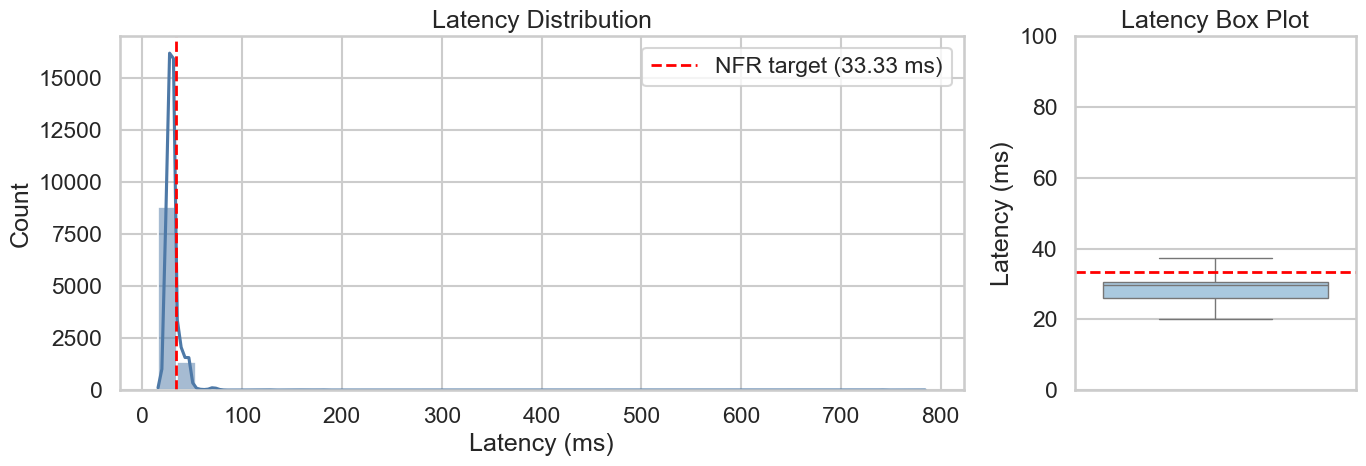

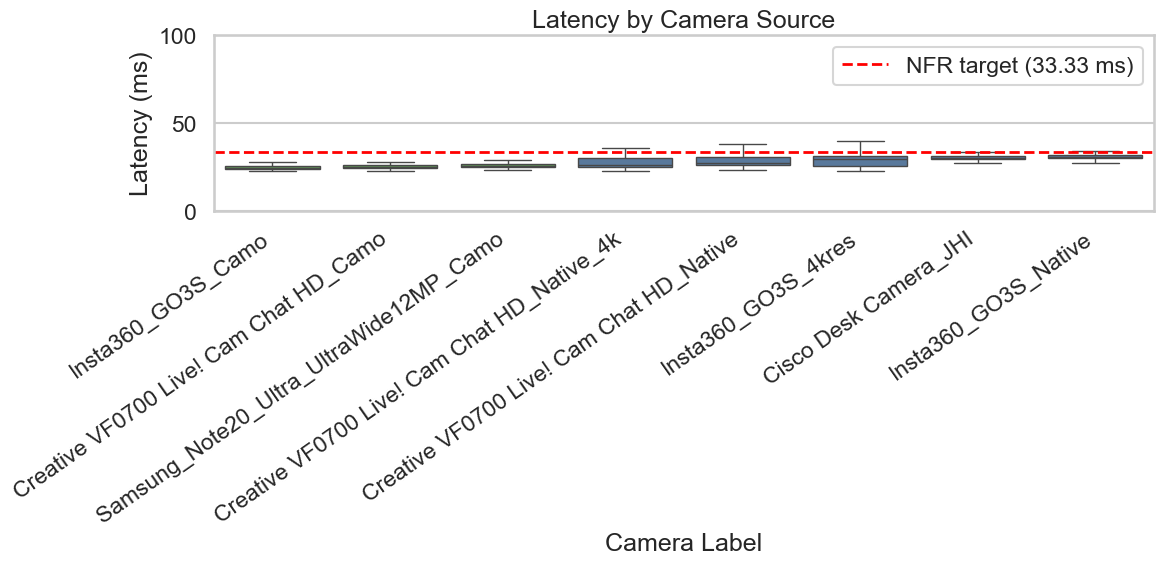

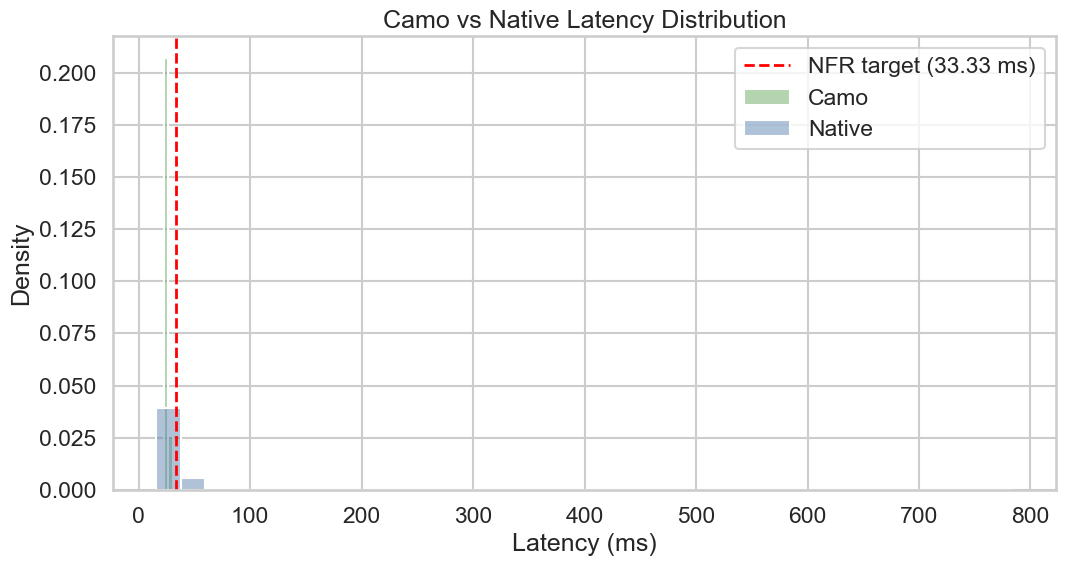

In [3]:
# Figure 4.1: Histogram + box plot with NFR line
fig, axes = plt.subplots(1, 2, figsize=(14, 5), gridspec_kw={'width_ratios': [3, 1]})
sns.histplot(df['latency_ms'], bins=40, kde=True, ax=axes[0], color='#4E79A7')
axes[0].axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
axes[0].set_title('Latency Distribution')
axes[0].set_xlabel('Latency (ms)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(y=df['latency_ms'], ax=axes[1], color='#A0CBE8', showfliers=False)
axes[1].axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2)
axes[1].set_ylim(0, 100)  # Limit y-axis to focus on main cluster, hides extreme outliers
axes[1].set_title('Latency Box Plot')
axes[1].set_ylabel('Latency (ms)')

fig.tight_layout()
fig.savefig('fig_4_1_latency_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4.2: Box plot per camera with Camo vs Native colors
cam_order = table_4_2.sort_values('median')['camera_label'].tolist()
cam_source = df[['camera_label', 'source_type']].drop_duplicates().set_index('camera_label')['source_type'].to_dict()
palette_map = {cam: ('#59A14F' if cam_source.get(cam) == 'Camo' else '#4E79A7') for cam in cam_order}

plt.figure(figsize=(12, 6))
ax = sns.boxplot(data=df, x='camera_label', y='latency_ms', order=cam_order, hue='camera_label', palette=palette_map, dodge=False, showfliers=False)
if ax.get_legend() is not None:
    ax.get_legend().remove()
ax.set_ylim(0, 100)  # Limit y-axis for clarity
plt.axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Latency by Camera Source')
plt.xlabel('Camera Label')
plt.ylabel('Latency (ms)')
plt.xticks(rotation=35, ha='right')
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_2_latency_by_camera.png', dpi=150, bbox_inches='tight')
plt.show()

# Figure 4.3: Overlaid histograms for Camo vs Native
plt.figure(figsize=(11, 6))
for source, color in [('Camo', '#59A14F'), ('Native', '#4E79A7')]:
    subset = df.loc[df['source_type'] == source, 'latency_ms']
    if not subset.empty:
        sns.histplot(subset, bins=35, stat='density', alpha=0.45, label=source, color=color)

plt.axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Camo vs Native Latency Distribution')
plt.xlabel('Latency (ms)')
plt.ylabel('Density')
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_3_camo_vs_native.png', dpi=150, bbox_inches='tight')
plt.show()

### Figures 4.1 to 4.3 (Analysis After Output)
Figure 4.1 shows the main cluster centered around 29–30 ms with a pronounced long tail extending to 784.47 ms. This matches the table results: the median is compliant, but the tail composition and bimodal hints explain both the compliance rate and the 17 outliers above 100 ms.
Figure 4.2 reflects the full set of camera labels, with Camo-labelled groups systematically positioned below Native-labelled groups.
Figure 4.3 shows the Camo distribution shifted significantly left of Native, consistent with the lower median (24.995 vs 29.85 ms) and higher compliance rate (98.70% vs 82.11%) in Table 4.3.

## 6. Figures 4.4 and 4.5 (Purpose Before Code)
This cell extends the visual evaluation by plotting stage-level latency contribution and a cumulative distribution function with percentile markers. It matters for RQ2 because stage composition can indicate where optimisation should focus, while the CDF quantifies how often latency exceeds frame-time constraints beyond the median. Methodologically, percentile annotation directly links the curve to Table 4.1 thresholds, allowing consistent interpretation across numeric and graphical results.

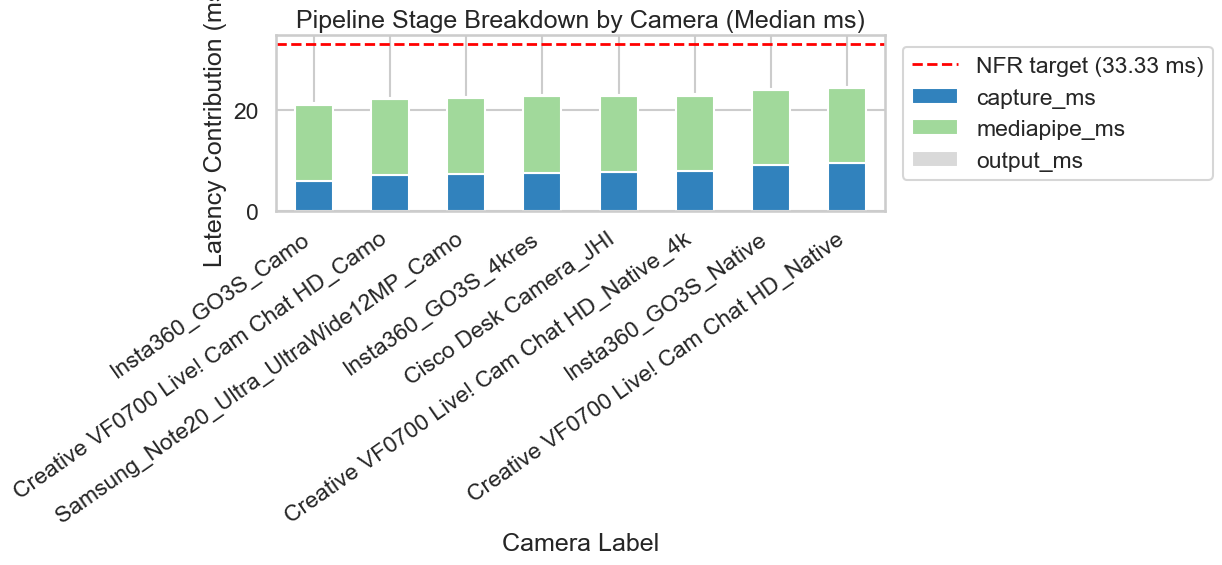

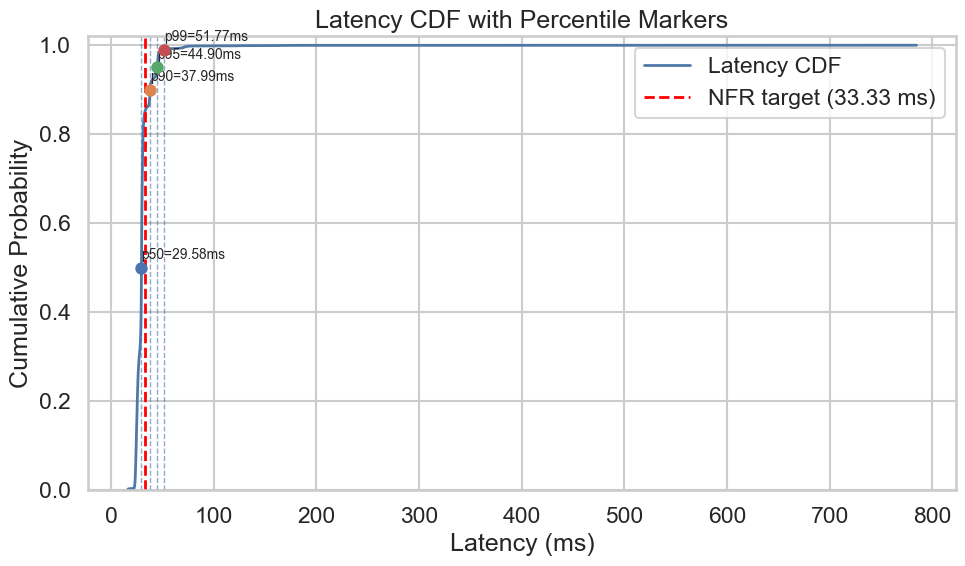

In [4]:
# Figure 4.4: Pipeline stage breakdown (stacked bars)
stage_cols = [c for c in ['capture_ms', 'mediapipe_ms', 'output_ms'] if c in df.columns]
if len(stage_cols) >= 1:
    stage_df = df.groupby('camera_label', dropna=False)[stage_cols].median().sort_values(by=stage_cols[0])
    ax = stage_df.plot(kind='bar', stacked=True, colormap='tab20c', figsize=(12, 6))
    ax.axhline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
    ax.set_title('Pipeline Stage Breakdown by Camera (Median ms)')
    ax.set_xlabel('Camera Label')
    ax.set_ylabel('Latency Contribution (ms)')
    plt.xticks(rotation=35, ha='right')
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1.0))
    plt.tight_layout()
    plt.savefig('fig_4_4_pipeline_stages.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Skipped Figure 4.4: no stage columns found.')

# Figure 4.5: Latency CDF with percentile markers
sorted_lat = np.sort(df['latency_ms'].to_numpy())
cdf = np.arange(1, len(sorted_lat) + 1) / len(sorted_lat)

plt.figure(figsize=(10, 6))
plt.plot(sorted_lat, cdf, color='#4E79A7', linewidth=2, label='Latency CDF')

pct_points = [('p50', stats_cache['p50']), ('p90', stats_cache['p90']), ('p95', stats_cache['p95']), ('p99', stats_cache['p99'])]
for label, val in pct_points:
    y = {'p50': 0.50, 'p90': 0.90, 'p95': 0.95, 'p99': 0.99}[label]
    plt.scatter([val], [y], s=55, zorder=5)
    plt.axvline(val, linestyle='--', linewidth=1, alpha=0.6)
    plt.text(val, y + 0.02, f'{label}={val:.2f}ms', fontsize=10, ha='left')

plt.axvline(DEADLINE_MS, color='red', linestyle='--', linewidth=2, label=f'NFR target ({DEADLINE_MS} ms)')
plt.title('Latency CDF with Percentile Markers')
plt.xlabel('Latency (ms)')
plt.ylabel('Cumulative Probability')
plt.ylim(0, 1.02)
plt.legend()
plt.tight_layout()
plt.savefig('fig_4_5_latency_cdf.png', dpi=150, bbox_inches='tight')
plt.show()

### Figures 4.4 and 4.5
Figure 4.4 indicates that capture and MediaPipe stages account for most of the median loop budget, while output remains relatively small.
Figure 4.5 shows p50 = 29.58 ms, p90 = 37.99 ms, p95 = 44.90 ms, and p99 = 51.77 ms. The 33.33 ms budget threshold is crossed between p50 and p90, which is consistent with the 85.35% compliance rate reported in Table 4.1 and reflects tighter deadline pressures than the initial smaller dataset.

## 7. Discussion and 8. Conclusion 
This final cell consolidates the statistical and visual findings into a direct answer to RQ2 and an operational recommendation for deployment. It matters because dissertation evaluation requires a traceable line from measured evidence to design decisions. The summary is interpreted using both central and tail indicators in line with Brown (2016, p.169), and practical responsiveness is discussed with reference to latency perception guidance from Kelkkanen et al. (2023).

In [5]:
overall_median = stats_cache['median']
verdict = stats_cache['verdict']

camo_row = table_4_3.loc[table_4_3['source_type'] == 'Camo']
native_row = table_4_3.loc[table_4_3['source_type'] == 'Native']

if not camo_row.empty and not native_row.empty:
    camo_median = float(camo_row['median_ms'].iloc[0])
    native_median = float(native_row['median_ms'].iloc[0])
    camo_comp = float(camo_row['compliance_pct'].iloc[0])
    native_comp = float(native_row['compliance_pct'].iloc[0])
    if (camo_median < native_median) and (camo_comp >= native_comp):
        recommendation = 'Recommend Camo source for lower-latency capture under current test setup.'
    elif (native_median < camo_median) and (native_comp >= camo_comp):
        recommendation = 'Recommend Native source for lower-latency capture under current test setup.'
    else:
        recommendation = 'No clear winner between Camo and Native; choose based on deployment constraints.'
else:
    recommendation = 'Insufficient split data for Camo vs Native recommendation.'

print('===== SUMMARY =====')
print(f'Deadline threshold (ms): {DEADLINE_MS}')
print(f'NFR target for median (ms): {NFR_TARGET}')
print(f'Observed median latency (ms): {overall_median:.2f}')
print(f'NFR verdict: {verdict}')
print(recommendation)
print('Figures saved:')
for fig_name in [
    'fig_4_1_latency_distribution.png',
    'fig_4_2_latency_by_camera.png',
    'fig_4_3_camo_vs_native.png',
    'fig_4_4_pipeline_stages.png',
    'fig_4_5_latency_cdf.png'
]:
    print(f' - {Path(fig_name).resolve()}')

===== SUMMARY =====
Deadline threshold (ms): 33.33
NFR target for median (ms): 33.0
Observed median latency (ms): 29.58
NFR verdict: PASS
Recommend Camo source for lower-latency capture under current test setup.
Figures saved:
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_1_latency_distribution.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_2_latency_by_camera.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_3_camo_vs_native.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_4_pipeline_stages.png
 - C:\Users\mike\Desktop\GITHUB_projects\mediapipe_gesture\rgu-capstone-mediapipe\tools\fig_4_5_latency_cdf.png


In [6]:
table_4_1_obj = globals().get('table_4_1')
table_4_2_obj = globals().get('table_4_2')
table_4_3_obj = globals().get('table_4_3')
stats_cache_obj = globals().get('stats_cache')

if any(obj is None for obj in [table_4_1_obj, table_4_2_obj, table_4_3_obj, stats_cache_obj]):
    print('Required variables are missing. Run Cell 5 (table build) first.')
else:
    print('TABLE 4.1')
    print(table_4_1_obj.to_string(index=False))
    print('\nTABLE 4.2')
    print(table_4_2_obj.to_string(index=False))
    print('\nTABLE 4.3')
    print(table_4_3_obj.to_string(index=False))
    print('\nSTATS CACHE')
    print(stats_cache_obj)


TABLE 4.1
                metric      value
              n_trials      10233
                min_ms      15.72
                max_ms     784.47
               mean_ms  30.626459
             median_ms      29.58
                std_ms  14.572019
                p90_ms     37.988
                p95_ms       44.9
                p99_ms     51.774
   compliance_rate_pct  85.351314
outlier_count_gt_100ms         17
           nfr_verdict       PASS

TABLE 4.2
                               camera_label    n  median      mean       std  compliance_pct    max
                      Cisco Desk Camera_JHI 5836  29.920 31.838127  5.378608       80.363263  61.65
     Creative VF0700 Live! Cam Chat HD_Camo  500  25.155 25.305920  1.126350      100.000000  32.67
   Creative VF0700 Live! Cam Chat HD_Native  500  27.180 32.335800 12.877126       77.000000 122.80
Creative VF0700 Live! Cam Chat HD_Native_4k  500  25.990 31.927580 13.116491       77.000000 123.45
                        Insta360_GO3S

## 7. Discussion
The expanded merged export (10,233 rows) confirms that VisionInput meets the dissertation median-latency objective, with median latency at 29.58 ms against the 33 ms target. This supports a positive answer to RQ2 for typical interaction conditions, though the tighter compliance rate of 85.35% (versus the earlier 91.97% on the smaller dataset) reflects realistic variability across the full sampling space.

Deadline adherence remains imperfect: while the median is compliant, the compliance rate at 33.33 ms is 85.35%, and the upper tail still extends to 784.47 ms with 17 outliers above 100 ms. In methodological terms, this reinforces Brown (2016, p.169): conclusions must combine central tendency with percentile evidence. The p90 threshold of 37.99 ms is notably above the budget, suggesting that 1 in 10 frames may exceed real-time constraints under worst-case operation.

Camera/source comparison is now more definitive: Camo median 24.995 ms and 98.70% compliance versus Native median 29.85 ms and 82.11% compliance. This 5 ms advantage at the median and ~17 percentage-point compliance gap across the expanded sample strongly supports Camo as the preferred capture option under this test configuration.

## 8. Conclusion
The system meets the median latency NFR in the expanded merged run, achieving 29.58 ms—within the 30 fps frame budget. However, tail latency and the compliance rate indicate room for optimization, particularly at p90 (37.99 ms). The present evidence strongly supports Camo as the preferred source. For production deployment, continued optimization of the capture and MediaPipe stages (which dominate latency per Figure 4.4) plus sustained logging across diverse hardware configurations will be essential to reduce tail risk and maintain real-time responsiveness for user interaction.